# Build a `Scene`: `Target`

A scene is a composition of three elements:
- A pointsource (`target`)
- A continuum flat background  (`background`)
- A structured background (`host`).

`slicersim.Scene` takes as input these three elements, but they could be left as _None_, resulting to a corresponding null spectrum (np.zeros).

**In that example, we will build a type Ia Supernovae scene that has no host background but zodiacal light**

***
## A Target : Supernovae

A Supernova need three elements:
- a `model_func`, i.e. any func such that `flux = model_func(lbda, *args, **kwargs)`
- a `position`, (x,y)

For simplicity, model based [sncosmo](https://sncosmo.readthedocs.io/en/stable) have been implemented in `slicersim`.

### Example: salt2 Type Ia Supernovae
Let's build from scratch a Supernovae assuming a the "_salt2-extented_" model from [sncosmo](https://sncosmo.readthedocs.io/en/stable) with a _x1=-1_ and _c=0.4_

In [1]:
from slicersim.scene import pointsource

In [2]:
parameters = dict(redshift=0.1, c=0.1, x1=-1) # store true values
model_func = pointsource.get_saltmodel_flux

In [3]:
position = (-0.4, 2) # position in the slicer

In [4]:
supernovae = pointsource.PointSource(model_func=model_func, 
                                     position=position, 
                                    meta=parameters)

### to get a flux, need a phase and a wavelength

But those could be set as config parameters

In [5]:
import numpy as np
lbda = np.linspace(3_300, 17_000, 500)
phase= -5 # obs-frame phase

In [6]:
lbda, flux = supernovae.get_spectrum(lbda, phase=phase)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

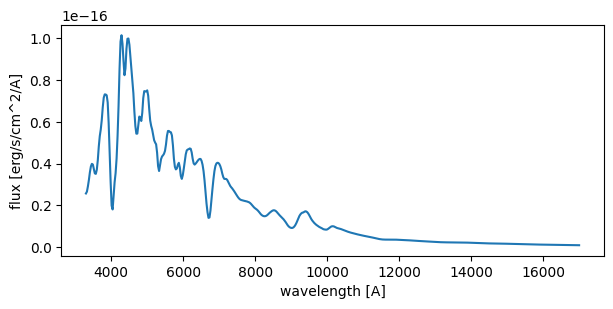

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux)
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

In [8]:
kwargs = supernovae._parse_model_kwargs_()
kwargs.pop("abmag")

## update any parameters you want

In [9]:
supernovae.mutable_parameters

['lbda',
 'phase',
 'abmag',
 'redshift',
 'MBmax',
 'source',
 'cosmo',
 'x1',
 'c',
 'alpha',
 'beta',
 'position']

let's change the redshift and sn stretch and color

In [10]:
supernovae.update(redshift=0.4, c=-0.05, x1=1.5)

the target metadata are now updated as will as the model

In [11]:
supernovae.meta

{'redshift': 0.4, 'c': -0.05, 'x1': 1.5, 'position': (-0.4, 2)}

In [12]:
up_lbda, up_flux = supernovae.get_spectrum(lbda, phase=phase)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

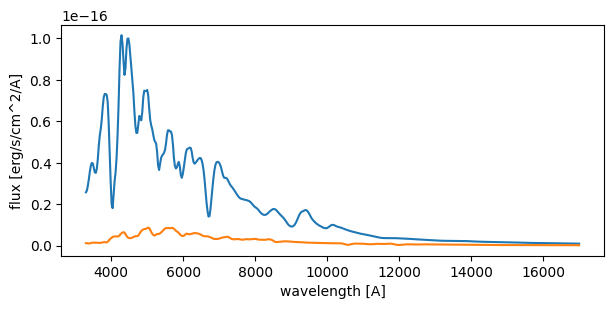

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial")
ax.plot(up_lbda, up_flux, label="updated")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Load Supernovae from a config file

You may want to set the model and position parameters in a config dictionary. 

Just use the `.from_config()` to load a supernovae instance from this configuration

In [14]:
from slicersim import iotools
sn_config = iotools.get_config()["scene"]["point_source"]
sn_config

{'name': 'SN Ia',
 'source': 'salt2-extended',
 'redshift': 1.5,
 'phase': 0,
 'MBmax': -19.3,
 'position': [1, 0.5],
 'c': 0,
 'x1': 0}

In [15]:
supernovae = pointsource.PointSource.from_config(sn_config)

In [16]:
lbda, flux = supernovae.get_spectrum(lbda)

Text(0, 0.5, 'flux [erg/s/cm^2/A]')

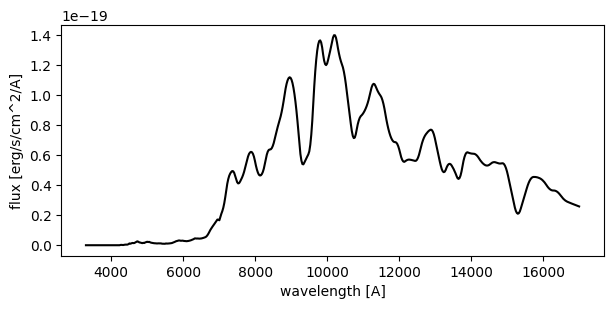

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial", color="k")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")

# Link with `Spectrograph`

In practice the lbda is given by the spectrograph. In the code that is simply done as follows

In [18]:
import slicersim

In [19]:
spectro_config = iotools.get_config()["spectrograph"]
spectrograph = slicersim.Spectrograph.from_config(spectro_config)

In [20]:
lbda, flux = supernovae.get_spectrum(spectrograph.lbda)

Text(0.5, 1.0, 'Supernovae at spectrograph resolution')

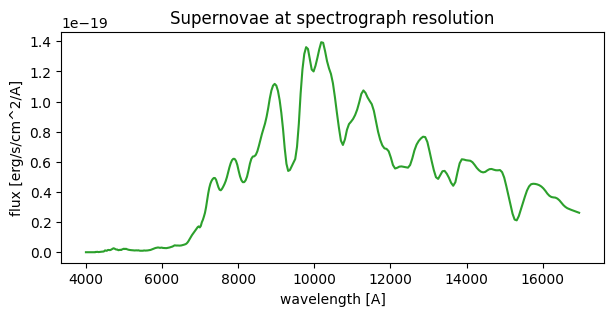

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=[7,3])
ax.plot(lbda, flux, label="initial", color="tab:green")
ax.set_xlabel("wavelength [A]")
ax.set_ylabel("flux [erg/s/cm^2/A]")
ax.set_title("Supernovae at spectrograph resolution")